In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import pyranges1 as pr

## Import mm39 annotations

In [2]:
ann = pr.read_gtf("data/gencode.vM39.basic.annotation.gtf")

## Import mm39 rmsk

In [3]:
rmsk_cols = [
    "bin", "swScore", "milliDiv", "milliDel",
    "milliIns", "Chromosome", "Start", "End", "genoLeft",
    "strand", "repName", "repClass", "repFamily",
    "repStart", "repEnd", "repLeft", "id"
]

df = pd.read_csv(
    "data/rmsk.txt",
    sep="\t",
    header=None,
    names=rmsk_cols
)

rmsk = pr.PyRanges(df)

## Filter retrotransposons and protein coding transcripts

In [4]:
families = ['LINE', 'SINE', 'LTR']

In [5]:
retrotransposons = rmsk[rmsk['repClass'].isin(families)]

In [6]:
transcripts = ann[(ann['Feature'] == 'transcript') & (ann['gene_type'] == 'protein_coding')]

# Isolate a single nucleotide for TSS
mask = transcripts["Strand"] == '+'
transcripts.loc[mask, "End"] = transcripts.loc[mask, "Start"]
transcripts.loc[~mask, "Start"] = transcripts.loc[~mask, "End"]

In [7]:
def plot_nearest(nearest, N, label=None, p_max=0.99):
    """Plots a CDF of the Distance column in 'nearest'

    Parameters
    ----------
    nearest : df
        The base cost of the item.
    N : integer
        The total number of rows we found a nearest neighbor for
    label : string, optional
        The label for the line to be plotted
    p_max: float, optional (default: 0.99)
        The CDF probability at which x_lim is placed

    Returns
    -------
    x_lim
        The x-value where the CDF hits 'p_max'% of its max
        Used to prevent the graph from zooming out too much
    """

    distances = nearest.drop_duplicates()[['Distance']].sort_values('Distance').to_numpy()
    cdf = np.arange(1, len(distances) + 1) / N
    plt.plot(distances, cdf, label=label)

    return distances[np.searchsorted(cdf, max(cdf) * p_max)]

# Measuring from TSSs to their nearest TE

In [8]:
nearest_TEs = transcripts.nearest_ranges(retrotransposons)[['transcript_id', 'repClass_b', 'Distance']]

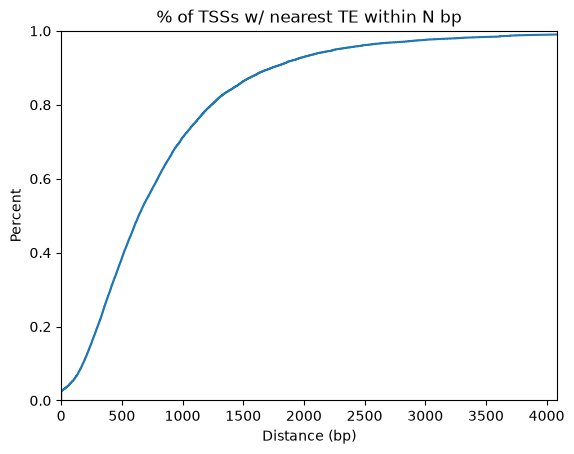

In [9]:
x_lim = plot_nearest(nearest_TEs, len(transcripts))

plt.xlim(0,x_lim)
plt.ylim(0, 1)

plt.title('% of TSSs w/ nearest TE within N bp')
plt.xlabel("Distance (bp)")
plt.ylabel("Percent")

plt.show()

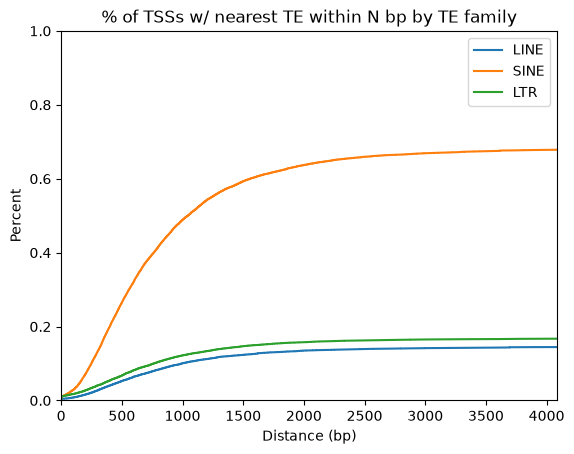

In [10]:
for family in families:
    plot_nearest(nearest_TEs[nearest_TEs['repClass_b'] == family], len(transcripts), label=family)

plt.ylim(0, 1)
plt.xlim(0,x_lim)

plt.title('% of TSSs w/ nearest TE within N bp by TE family')
plt.xlabel("Distance (bp)")
plt.ylabel("Percent")
plt.legend()

plt.show()

# Measuring from TSSs to their nearest TE from a specific family

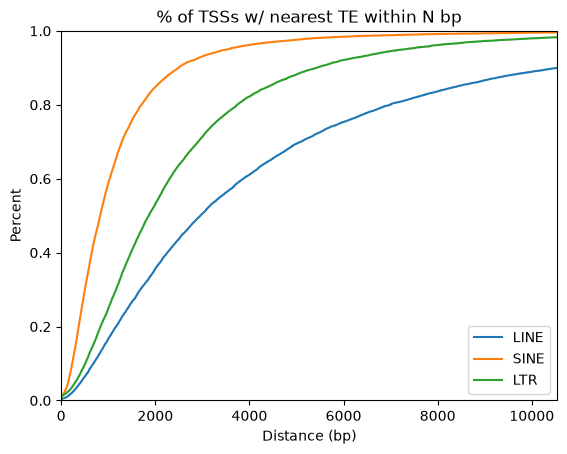

In [11]:
x_lim = 0

for family in families:
    nearest_TEs = transcripts.nearest_ranges(retrotransposons[retrotransposons['repClass'] == family])
    x_lim = max(x_lim, plot_nearest(nearest_TEs[['transcript_id', 'repClass_b', 'Distance']], len(transcripts), label=family, p_max=0.9))

plt.ylim(0, 1)
plt.xlim(0,x_lim)

plt.title('% of TSSs w/ nearest TE within N bp')
plt.xlabel("Distance (bp)")
plt.ylabel("Percent")
plt.legend()

plt.show()

# Measuring from TEs to their nearest TSS

In [12]:
retrotransposons['retrotransposon_id'] = np.arange(len(retrotransposons))
nearest_TSSs = retrotransposons.nearest_ranges(transcripts)

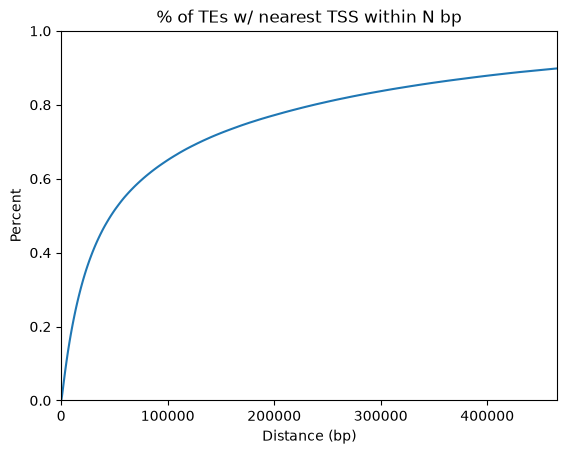

In [13]:
x_lim = plot_nearest(nearest_TSSs[['retrotransposon_id', 'repClass', 'Distance']], len(retrotransposons), p_max=0.9)

plt.ylim(0, 1)
plt.xlim(0,x_lim)

plt.title('% of TEs w/ nearest TSS within N bp')
plt.xlabel("Distance (bp)")
plt.ylabel("Percent")

plt.show()

# Measuring from TEs by family to their nearest TSS

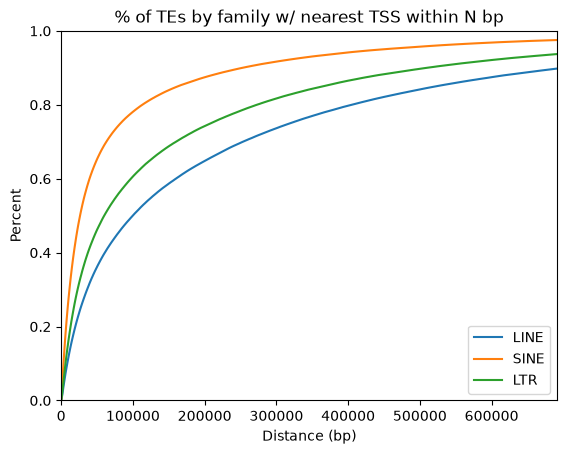

In [14]:
x_lim = 0
for family in families:
    te_in_family = retrotransposons[retrotransposons['repClass'] == family]
    nearest_TSSs = te_in_family.nearest_ranges(transcripts)
    x_lim = max(x_lim, plot_nearest(nearest_TSSs[['retrotransposon_id', 'repName', 'Distance']], len(te_in_family), label=family, p_max=0.9))

plt.ylim(0, 1)
plt.xlim(0,x_lim)

plt.title('% of TEs by family w/ nearest TSS within N bp')
plt.xlabel("Distance (bp)")
plt.ylabel("Percent")
plt.legend()

plt.show()